In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("iq_cgpa_org.csv")
df.head()

,IQ,CGPA
0,6.75,2.70
1,1.23,0.06
2,3.48,1.30
3,3.01,1.35
4,7.63,2.88


In [5]:
df.shape

(1000, 2)

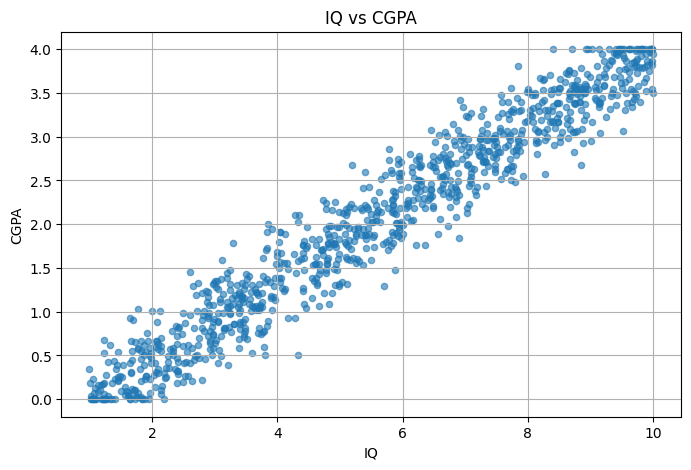

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df['IQ'], df['CGPA'], s =20, alpha=0.6 )

plt.xlabel("IQ")
plt.ylabel("CGPA")
plt.title("IQ vs CGPA")
plt.grid(True)
plt.show()

In [11]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [12]:
X

,IQ
0,6.75
1,1.23
2,3.48
3,3.01
4,7.63
...,...
995,1.29
996,4.33
997,4.99
998,9.55


In [13]:
y

0      2.70
1      0.06
2      1.30
3      1.35
4      2.88
       ... 
995    0.04
996    2.02
997    1.97
998    3.63
999    3.59
Name: CGPA, Length: 1000, dtype: float64

In [14]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train

,IQ
29,6.43
535,7.90
695,6.63
557,9.85
836,6.89
...,...
106,2.00
270,8.35
860,8.85
435,1.45


In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
model = LinearRegression()

In [22]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
m = model.coef_
m

array([0.44260382])

In [24]:
b = model.intercept_
b

np.float64(-0.4255864973180836)

In [27]:
# Predict new

m * 7.63 + b

array([2.95148062])

In [34]:
model.predict(X_test)

array([1.41121934, 0.37995245, 2.68591833, 2.26101867, 3.00901912,
       0.84468646, 0.75616569, 1.52629633, 2.53985907, 0.29143169,
       1.30056839, 3.65964673, 0.72960946, 3.63751654, 3.32326783,
       2.30527905, 2.87623797, 3.22146895, 2.50887681, 3.72161126,
       0.31798791, 3.23474707, 2.88066401, 0.80927815, 1.07484044,
       0.49502944, 2.88951609, 3.7835758 , 3.91193091, 0.57912417,
       3.86767052, 0.53043775, 0.49945548, 0.52601171, 2.16364583,
       3.99602563, 1.17663932, 3.52686558, 1.19434347, 1.53072237,
       3.21261687, 3.98717355, 1.01287591, 1.2208997 , 3.53571766,
       2.22118433, 2.59297153, 2.88509005, 3.20819084, 0.63223662,
       2.83640363, 1.85382316, 3.51801351, 1.75202428, 0.63666266,
       3.23032103, 1.33597669, 0.88894684, 2.3229832 , 3.24802518,
       1.72104201, 2.59739757, 0.44634302, 3.94291317, 2.77001306,
       2.75673494, 3.97832148, 1.18549139, 0.85796457, 0.1188162 ,
       1.74759824, 0.13209431, 3.40736255, 3.43391878, 2.55313

In [28]:
y_pred = model.predict(X_test)

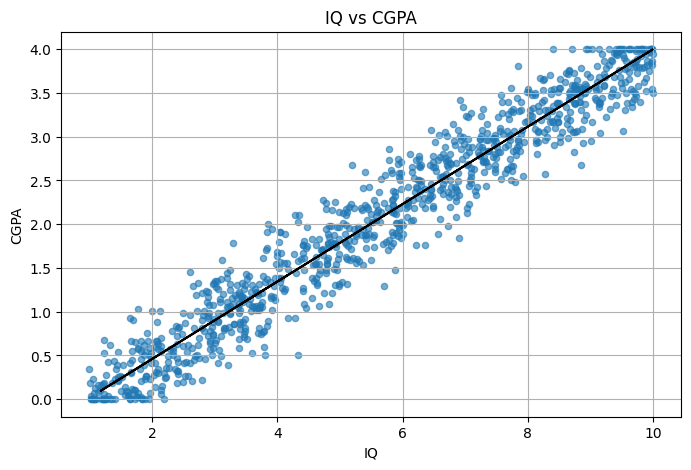

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(df["IQ"], df["CGPA"], s=20, alpha=0.6)
plt.plot(X_test, model.predict(X_test), color="black")

plt.xlabel("IQ")
plt.ylabel("CGPA")
plt.title("IQ vs CGPA")
plt.grid(True)
plt.show()

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [31]:
y_train.squeeze()

29     2.33
535    3.08
695    2.41
557    3.80
836    3.08
       ... 
106    1.01
270    3.70
860    3.55
435    0.22
102    2.63
Name: CGPA, Length: 800, dtype: float64

In [32]:
import math

In [33]:
print(f"MAE => {mean_absolute_error(y_test, y_pred)}")
print(f"MSE => {mean_squared_error(y_test, y_pred)}")
print(f"RMSE => {math.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"R2 => {r2_score(y_test, y_pred)}")

MAE => 0.21761282491267914
MSE => 0.0747040752677109
RMSE => 0.2733204625850595
R2 => 0.9496581378365819
